# Hypothesis 1 And Concept-Copying Analysis

This notebook combines the original `hypothesis1_analysis.ipynb` and `concept_copying_analysis.ipynb` workflows into a single analysis pass.

It uses the shared improbable-bigram traced cache, the coherent 2-token concept cache, and the random two-token control set, then runs:

- the Hypothesis 1 token-induction diagnostics
- the concept-copying head diagnostics

The shared repo-setup and cache-loading cell appears only once below.


In [ ]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.extend(
            [
                candidate,
                candidate / "dual-route-induction",
                candidate / "improbable-bigram-causality" / "dual-route-induction",
            ]
        )

    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

import analysis_utils as h1

h1 = importlib.reload(h1)

h1.configure_matplotlib()
CACHE = h1.load_cache(ROOT)
DEFAULT_TOP_K = 32
ROOT

WindowsPath('D:/uni/courses/S2026/CS_7180/Project/improbable-bigram-causality/dual-route-induction')

## Shared Cache Checks

Run this once to verify that the traced cache and control cache are both available before either analysis section.


In [93]:
display(Markdown(h1.trace_consistency_markdown(CACHE)))
overview = h1.dataset_overview(CACHE)
display(overview)

### Trace Consistency
The prompt-summary JSON is not present in this repo snapshot. The notebook therefore uses the traced cache directly.

,dataset,examples,hallucinated_second_token,copied
0,Improbable summary,100,33,67
1,Updated trace cache,100,33,67
2,2-token concept cache,36,0,36
3,Random phrase cache,35,0,35


# Hypothesis 1 Analysis

This notebook tests Hypothesis 1 for the improbable-bigram repetition setup:

- token induction heads should keep attending to the desired earlier suffix token, measured with `NTM`
- token induction heads should keep contributing to the correct second-token prediction, measured with `DLA`

The notebook uses the traced cache in `updated_table1_literal`, the coherent 2-token concept cache in `selected_two_token_concepts`, and the random two-token control set in `random_tokens`.


In [94]:
summary = h1.build_pairwise_summary(CACHE, DEFAULT_TOP_K)
display(summary.round(6))
display(Markdown(h1.interpretation_markdown(CACHE, DEFAULT_TOP_K)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Token NTM (raw),Hallucinated - Copied,0.024730,0.023275,0.001455,-0.000551,0.003349
1,Token NTM (raw),Hallucinated - 2-token concepts,0.024730,0.039227,-0.014497,-0.018362,-0.010812
2,Token NTM (raw),Hallucinated - Random,0.024730,0.048698,-0.023968,-0.028014,-0.020336
3,Token NTM (value-weighted),Hallucinated - Copied,0.041541,0.040771,0.000770,-0.002189,0.003553
4,Token NTM (value-weighted),Hallucinated - 2-token concepts,0.041541,0.061815,-0.020274,-0.025175,-0.015662
5,Token NTM (value-weighted),Hallucinated - Random,0.041541,0.074148,-0.032608,-0.038103,-0.027238
6,Token correct-token DLA,Hallucinated - Copied,0.027389,0.032406,-0.005017,-0.011759,0.001962
7,Token correct-token DLA,Hallucinated - 2-token concepts,0.027389,0.046175,-0.018786,-0.030460,-0.007621
8,Token correct-token DLA,Hallucinated - Random,0.027389,0.068041,-0.040652,-0.051702,-0.029943
9,Hallucinated token DLA,Wrong-token - Correct-token,0.004627,0.027389,-0.022763,-0.031545,-0.012939


### Hypothesis 1 Readout at Top-32
- Hallucinated vs copied NTM: `0.0015` (95% CI `-0.0006` to `0.0033`)
- Hallucinated vs copied correct-token DLA: `-0.0050` (95% CI `-0.0118` to `0.0020`)
- Hallucinated vs 2-token concepts NTM: `-0.0145` (95% CI `-0.0184` to `-0.0108`)
- Hallucinated vs 2-token concepts correct-token DLA: `-0.0188` (95% CI `-0.0305` to `-0.0076`)
- Hallucinated vs random NTM: `-0.0240` (95% CI `-0.0280` to `-0.0203`)
- Hallucinated vs random correct-token DLA: `-0.0407` (95% CI `-0.0517` to `-0.0299`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0228` (95% CI `-0.0315` to `-0.0129`)

Within the improbable-bigram set, the traced cache does not show a clear hallucination-specific token-head breakdown. The stronger claim that token-head behavior is similar across all conditions is harder to defend, because the 2-token concept and random-phrase controls are both stronger on the token-head metrics.

,metric,condition,k,mean,ci_low,ci_high
0,Token NTM (raw),Hallucinated improbable,8,0.046329,0.042530,0.050190
1,Token NTM (raw),Copied improbable,8,0.040627,0.037449,0.044055
2,Token NTM (raw),2-token concepts,8,0.052628,0.046561,0.059263
3,Token NTM (raw),Random phrases,8,0.082889,0.073416,0.093634
4,Token NTM (raw),Hallucinated improbable,16,0.031126,0.028741,0.033655
5,Token NTM (raw),Copied improbable,16,0.028339,0.026312,0.030403
6,Token NTM (raw),2-token concepts,16,0.051822,0.046948,0.057067
7,Token NTM (raw),Random phrases,16,0.058136,0.051863,0.065144
8,Token NTM (raw),Hallucinated improbable,32,0.024730,0.023345,0.026160
9,Token NTM (raw),Copied improbable,32,0.023275,0.021956,0.024709


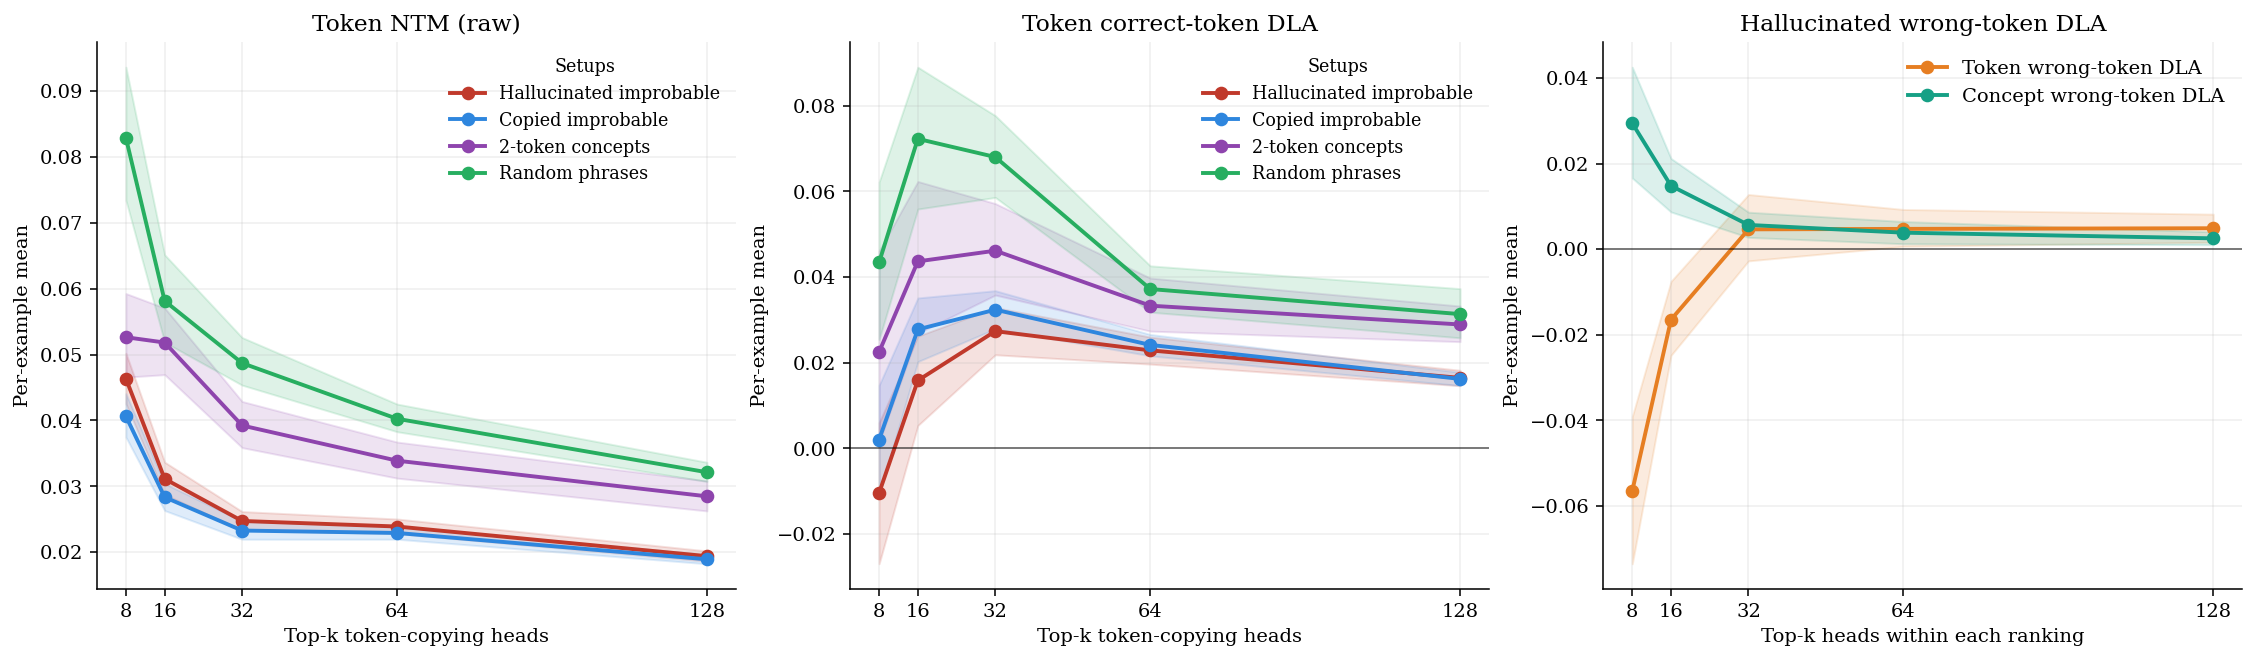

In [95]:
fig, axes, sweep = h1.plot_k_sweep(CACHE, ks=(8, 16, 32, 64, 128))
display(sweep.round(6))

(<Figure size 1680x784 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 token-head NTM'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 token-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

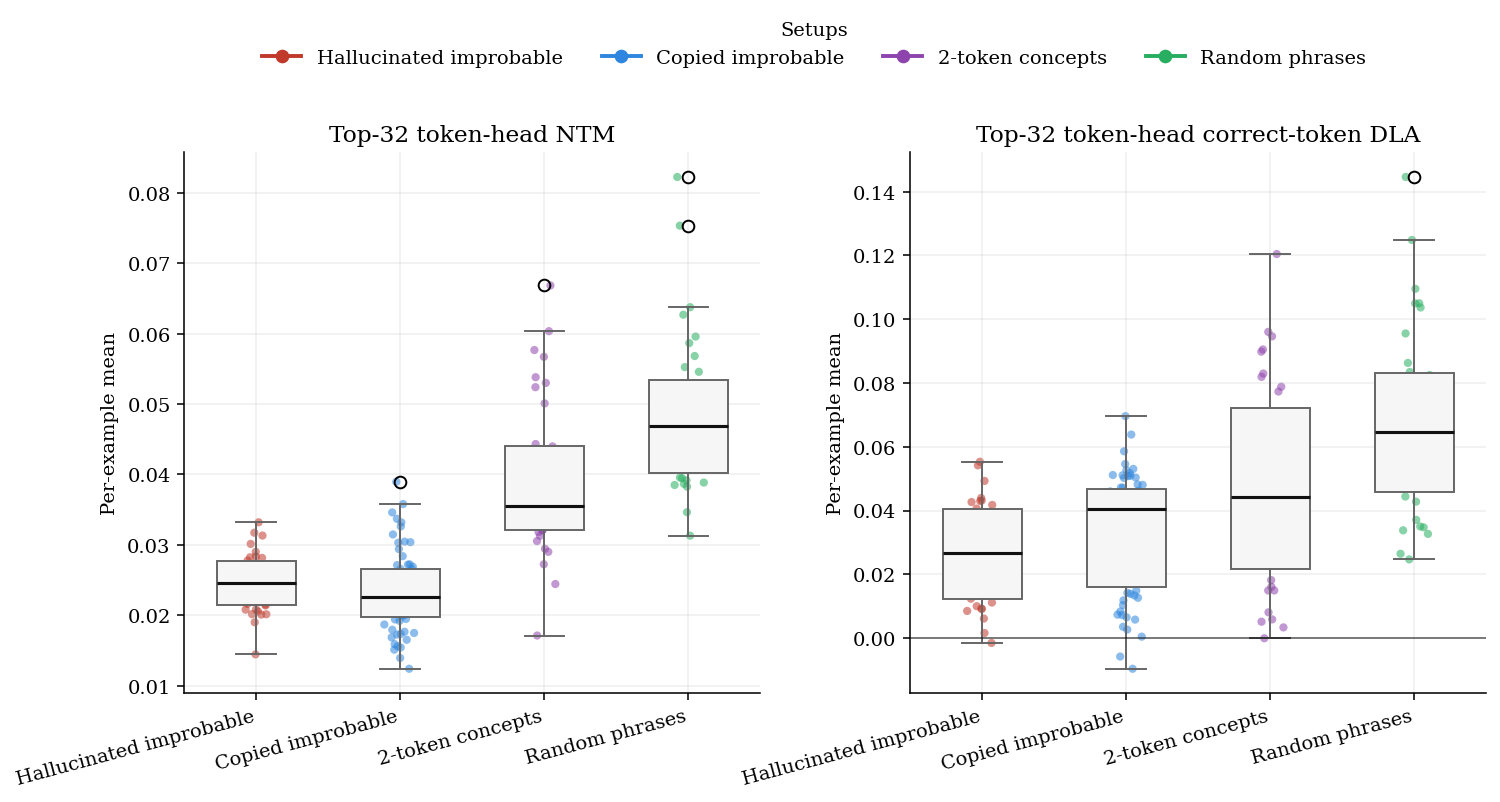

In [96]:
h1.plot_distribution_panels(CACHE, DEFAULT_TOP_K)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 token heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

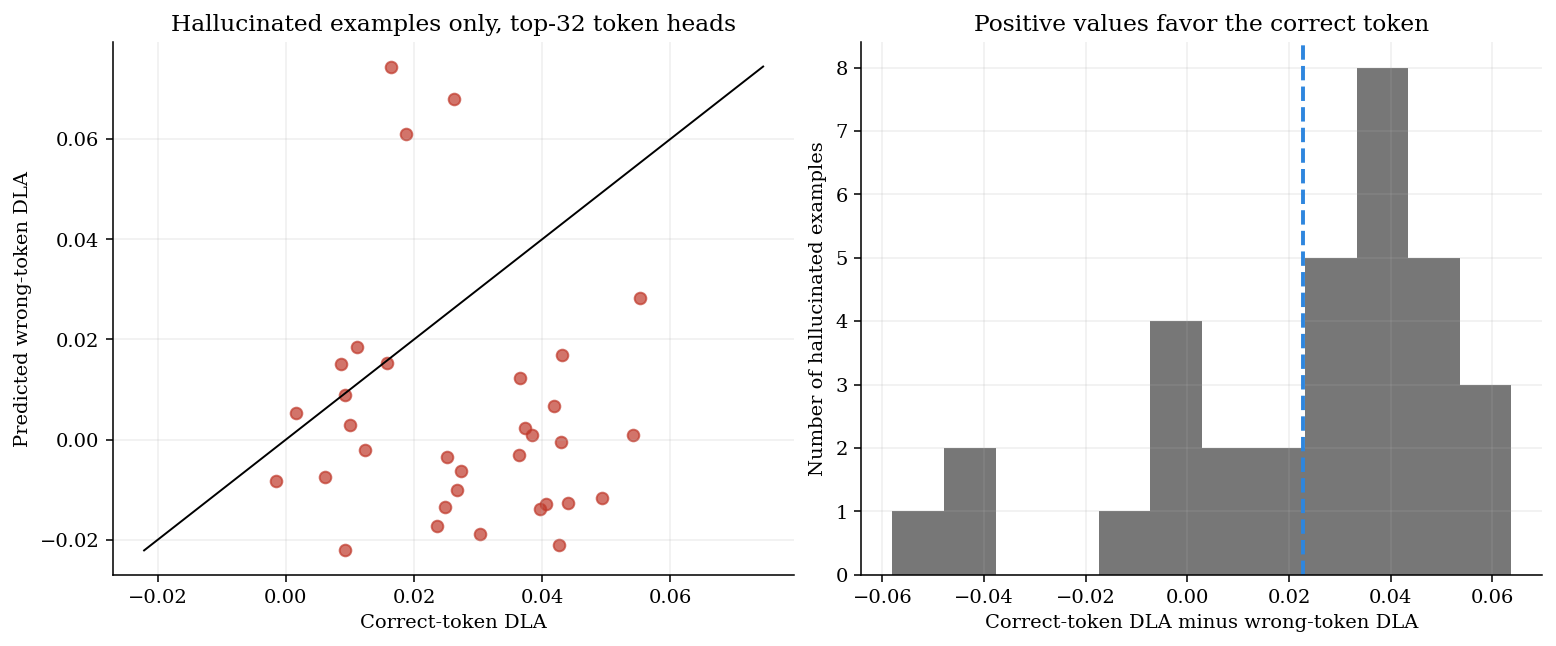

In [97]:
h1.plot_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1890x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 token heads: NTM'}>,
        <Axes: title={'center': 'Top-16 token heads: DLA'}>], dtype=object))

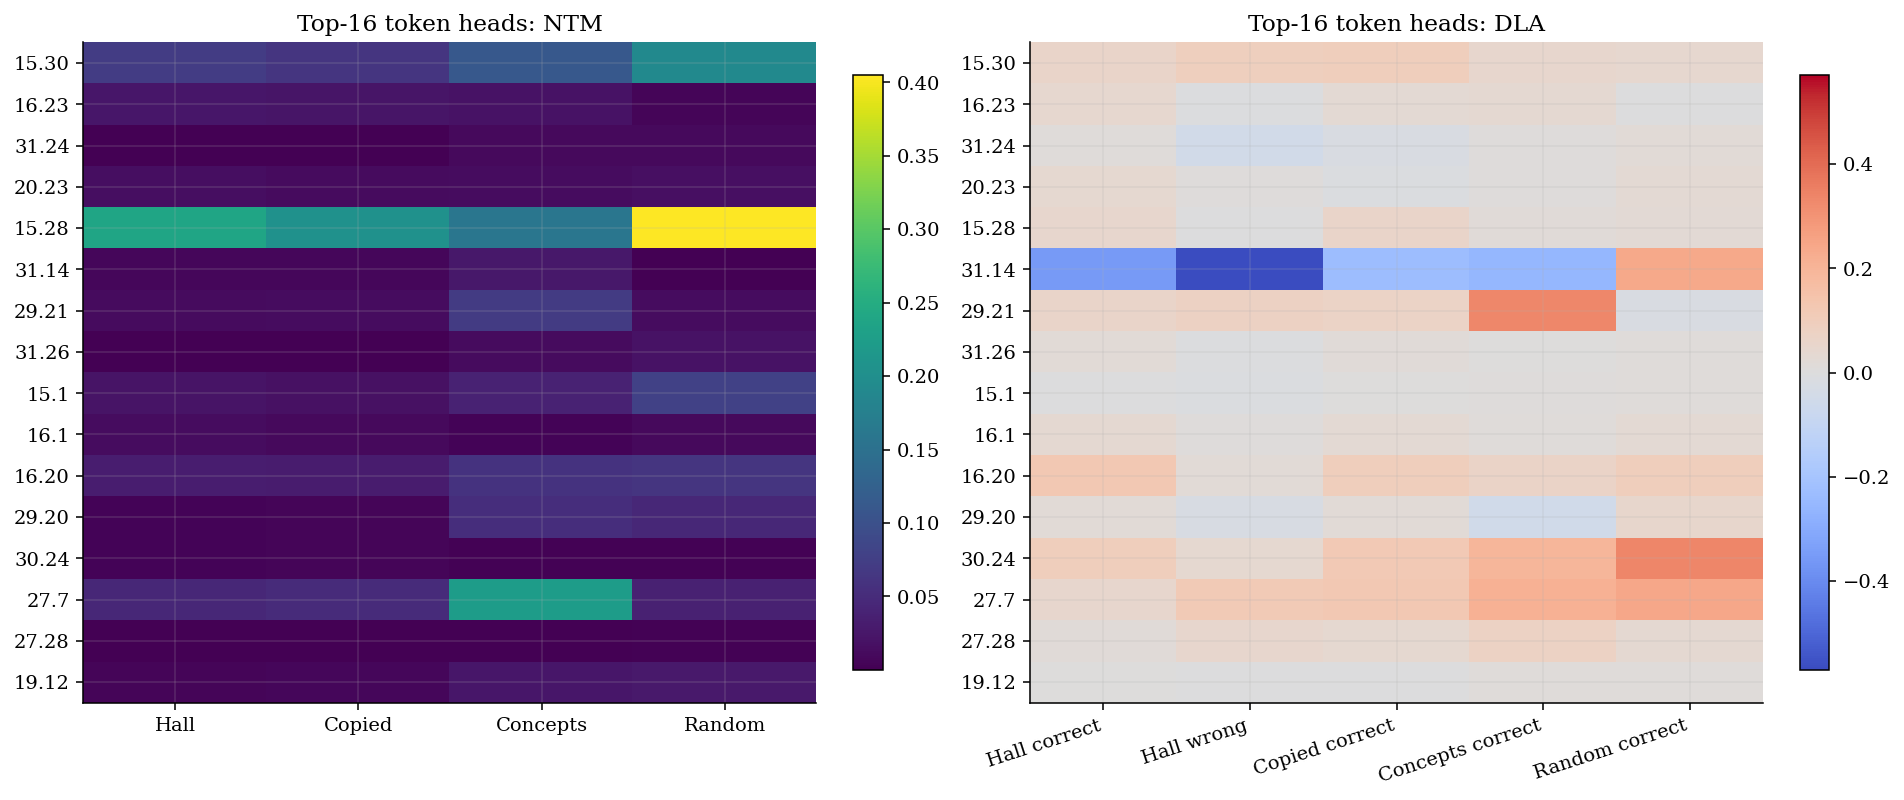

In [98]:
h1.plot_top_head_heatmap(CACHE, top_k=16)

## Are The Highest-DLA Heads Token-Copying Or Concept-Copying?

This section ranks heads by mean DLA and checks whether those heads also appear in the identified token-copying or concept-copying rankings.


In [99]:
TOP_DLA_N = 20
COMPARE_K = 32
SOURCES = [
    "hallucinated_correct",
    "hallucinated_wrong",
    "copied_correct",
    "concepts_correct",
    "random_correct",
]

membership_summary = h1.summarize_top_dla_membership(
    CACHE,
    sources=SOURCES,
    top_n=TOP_DLA_N,
    compare_k=COMPARE_K,
)
display(membership_summary)

for source in SOURCES:
    table = h1.top_dla_membership_table(
        CACHE,
        source=source,
        top_n=TOP_DLA_N,
        compare_k=COMPARE_K,
    )
    display(Markdown(f"### {table['source'].iloc[0]}"))
    display(
        table[
            [
                "head",
                "mean_dla",
                "membership_label",
                "in_token_top_k",
                "in_concept_top_k",
                "token_rank",
                "concept_rank",
            ]
        ].round({"mean_dla": 6})
    )

,source,top_n,compare_k,token_overlap,concept_overlap,both_overlap,neither_overlap,mean_token_rank,mean_concept_rank
0,Hallucinated correct-token DLA,20,32,3,1,0,16,289.70,348.55
1,Hallucinated wrong-token DLA,20,32,3,2,0,15,333.40,325.55
2,Copied-improbable correct-token DLA,20,32,3,2,0,15,342.85,315.90
3,2-token-concept correct-token DLA,20,32,4,1,0,15,316.05,375.55
4,Random-phrase correct-token DLA,20,32,4,0,0,16,315.25,420.15


### Hallucinated correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.630886,Token only,True,False,32,300
1,27.6,0.550378,Neither,False,False,675,164
2,26.13,0.407651,Neither,False,False,376,42
3,22.1,0.385917,Neither,False,False,401,154
4,26.3,0.381923,Neither,False,False,35,667
5,20.1,0.297932,Concept only,False,True,406,5
6,24.18,0.282678,Neither,False,False,150,624
7,29.9,0.205844,Neither,False,False,419,503
8,28.22,0.190377,Neither,False,False,373,175
9,31.20,0.183341,Neither,False,False,371,297


### Hallucinated wrong-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.468839,Token only,True,False,32,300
1,24.22,0.374964,Neither,False,False,156,223
2,29.9,0.287445,Neither,False,False,419,503
3,30.26,0.243680,Neither,False,False,103,482
4,31.5,0.222435,Neither,False,False,1003,289
5,27.6,0.212589,Neither,False,False,675,164
6,26.3,0.209088,Neither,False,False,35,667
7,28.0,0.202645,Neither,False,False,454,558
8,22.1,0.187615,Neither,False,False,401,154
9,26.13,0.179703,Neither,False,False,376,42


...

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.599462,Token only,True,False,32,300
1,27.6,0.464505,Neither,False,False,675,164
2,26.13,0.379171,Neither,False,False,376,42
3,26.3,0.355348,Neither,False,False,35,667
4,29.9,0.265404,Neither,False,False,419,503
5,20.1,0.225269,Concept only,False,True,406,5
6,27.20,0.218328,Concept only,False,True,397,4
7,31.20,0.210226,Neither,False,False,371,297
8,30.12,0.193650,Neither,False,False,553,378
9,31.21,0.160162,Neither,False,False,383,299


### 2-token-concept correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,30.26,1.020289,Neither,False,False,103,482
1,29.9,0.835700,Neither,False,False,419,503
2,31.1,0.788949,Token only,True,False,32,300
3,27.20,0.558011,Concept only,False,True,397,4
4,29.11,0.552935,Neither,False,False,609,409
5,28.18,0.370325,Neither,False,False,224,134
6,31.7,0.359431,Neither,False,False,792,296
7,29.21,0.330212,Token only,True,False,7,530
8,26.3,0.291607,Neither,False,False,35,667
9,31.6,0.280571,Neither,False,False,414,317


### Random-phrase correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.0,0.728313,Token only,True,False,20,318
1,27.4,0.509023,Neither,False,False,144,346
2,30.12,0.354871,Neither,False,False,553,378
3,28.20,0.353128,Neither,False,False,140,103
4,30.24,0.334439,Token only,True,False,13,336
5,24.18,0.307862,Neither,False,False,150,624
6,25.14,0.295445,Neither,False,False,99,643
7,30.30,0.294079,Neither,False,False,74,585
8,24.16,0.292921,Neither,False,False,597,398
9,25.15,0.285971,Neither,False,False,216,660


WindowsPath('D:/uni/courses/S2026/CS_7180/Project/improbable-bigram-causality/dual-route-induction/scripts/hypothesis1_figures')

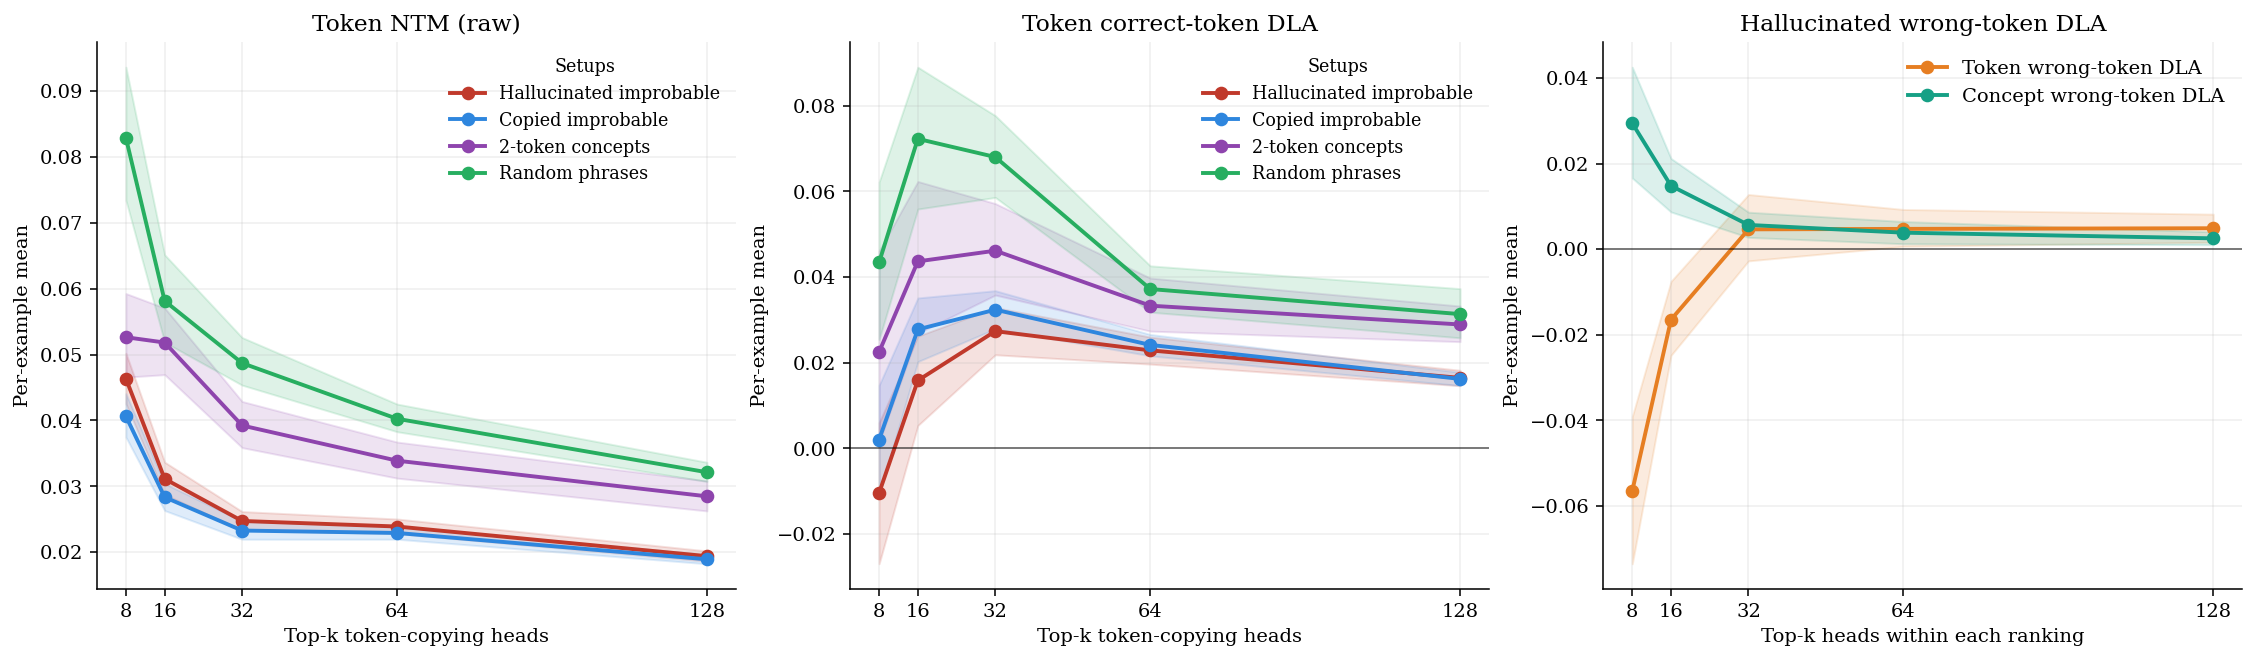

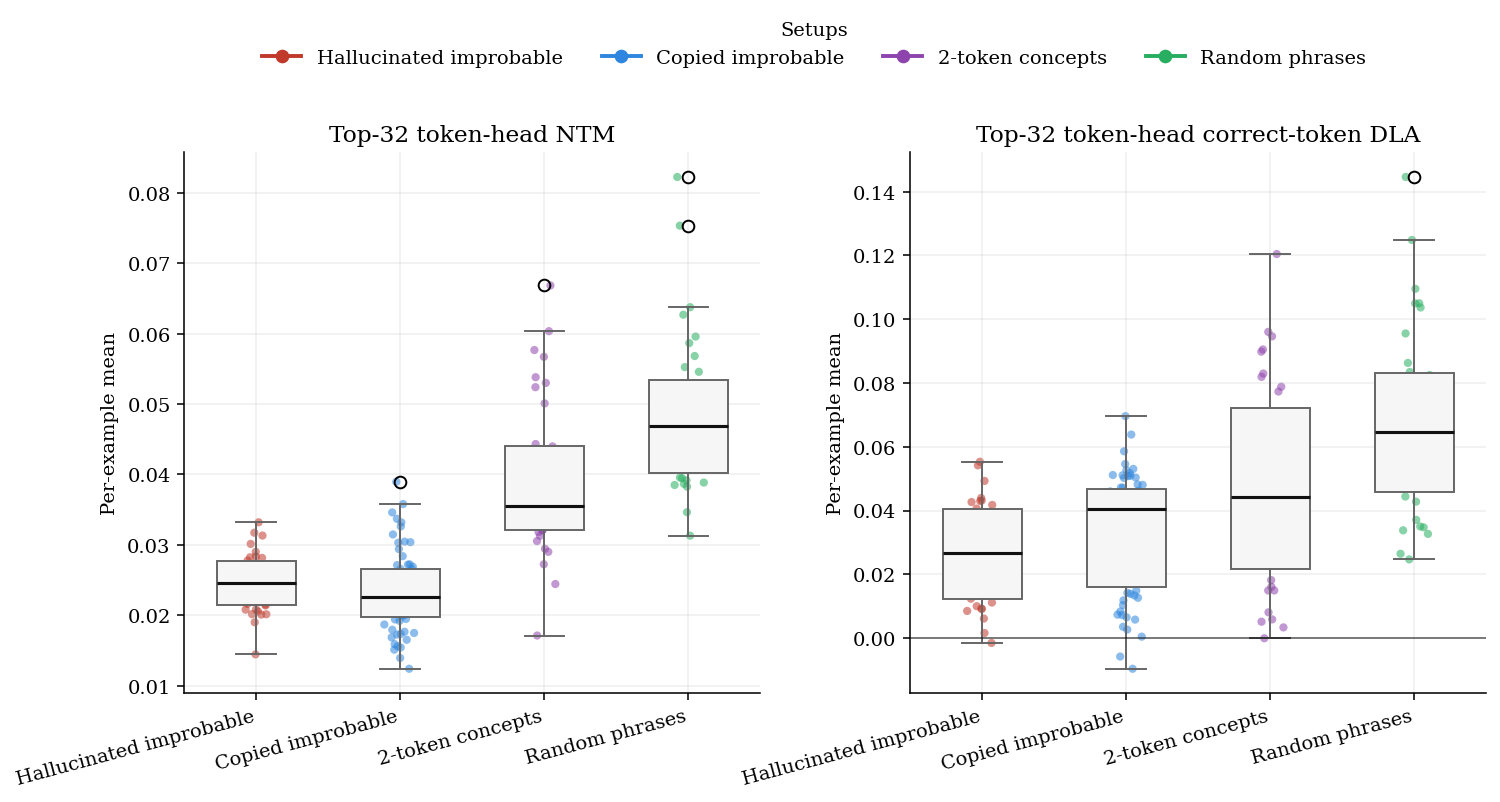

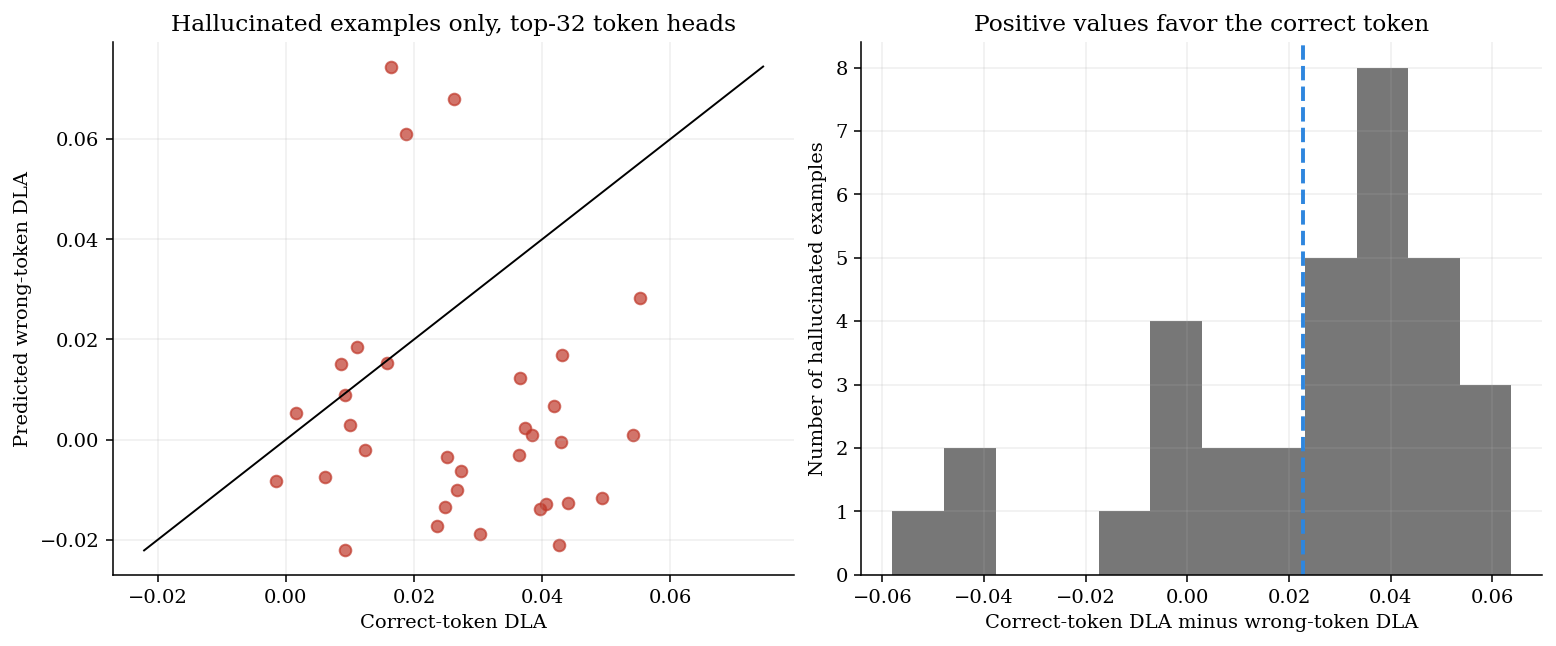

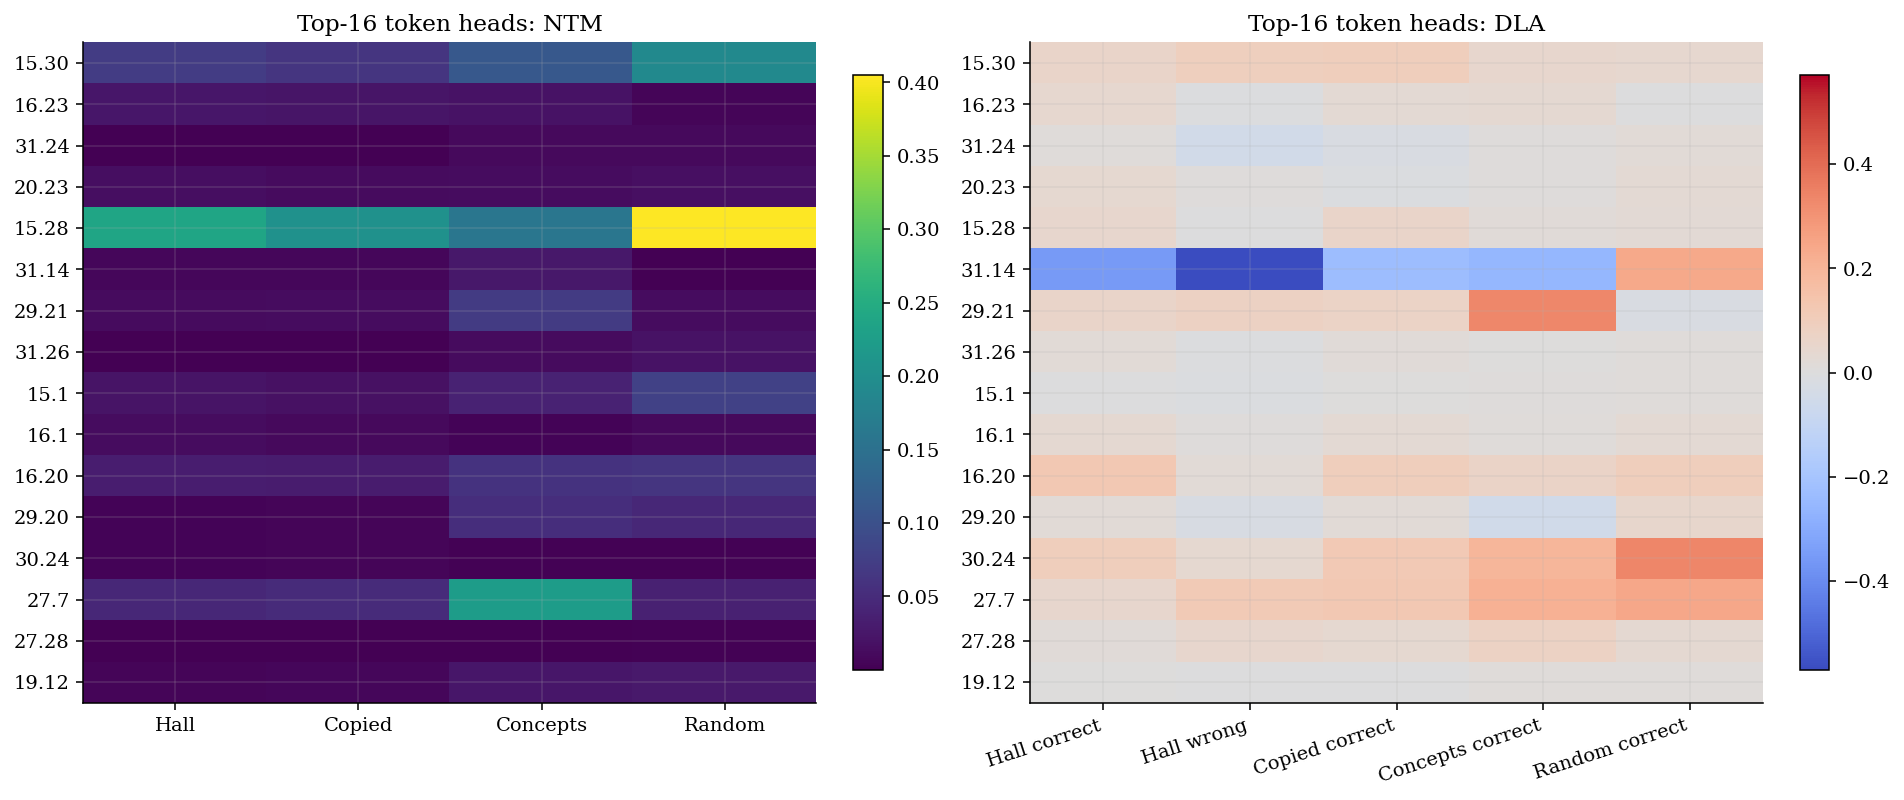

In [100]:
SAVE_DIR = ROOT / "scripts" / "hypothesis1_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_k_sweep(
    CACHE, ks=(8, 16, 32, 64, 128), save_path=SAVE_DIR / "hypothesis1_k_sweep.png"
)
_ = h1.plot_distribution_panels(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_distributions.png"
)
_ = h1.plot_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_hallucinated_dla_pair.png"
)
_ = h1.plot_top_head_heatmap(
    CACHE, top_k=16, save_path=SAVE_DIR / "hypothesis1_top_token_heads.png"
)
SAVE_DIR

---

# Concept-Copying Head Analysis

The cells below come from `concept_copying_analysis.ipynb` and reuse the same loaded cache and helper module from the setup cell above.


## Coverage

The proposal's concept-head diagnostic compares three conditions:

1. hallucinated improbable bigrams
2. random two-token phrases
3. coherent two-token concepts

All three conditions are now present in the current cache, with copied improbable examples still serving as an additional internal control. The notebook can therefore compare hallucinated prompts directly against both coherent 2-token concepts and random two-token phrases.


In [101]:
summary = h1.build_concept_pairwise_summary(CACHE, DEFAULT_TOP_K)
display(summary.round(6))
display(Markdown(h1.concept_interpretation_markdown(CACHE, DEFAULT_TOP_K)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Concept LTM (raw),Hallucinated - Copied,0.030744,0.030024,0.000720,-0.000875,0.002319
1,Concept LTM (raw),Hallucinated - 2-token concepts,0.030744,0.038565,-0.007821,-0.009881,-0.005651
2,Concept LTM (raw),Hallucinated - Random,0.030744,0.020199,0.010545,0.008477,0.012554
3,Concept LTM (value-weighted),Hallucinated - Copied,0.065061,0.063129,0.001933,-0.000598,0.004469
4,Concept LTM (value-weighted),Hallucinated - 2-token concepts,0.065061,0.073889,-0.008828,-0.012157,-0.005356
5,Concept LTM (value-weighted),Hallucinated - Random,0.065061,0.044835,0.020227,0.016865,0.023425
6,Concept correct-token DLA,Hallucinated - Copied,0.012735,0.014334,-0.001599,-0.004009,0.000796
7,Concept correct-token DLA,Hallucinated - 2-token concepts,0.012735,0.026890,-0.014156,-0.021587,-0.007403
8,Concept correct-token DLA,Hallucinated - Random,0.012735,0.008833,0.003902,0.000475,0.007102
9,Hallucinated concept DLA,Wrong-token - Correct-token,0.005659,0.012735,-0.007076,-0.010125,-0.003935


### Concept-Head Readout at Top-32
- Hallucinated vs copied LTM: `0.0007` (95% CI `-0.0009` to `0.0023`)
- Hallucinated vs copied correct-token DLA: `-0.0016` (95% CI `-0.0040` to `0.0008`)
- Hallucinated vs 2-token concepts LTM: `-0.0078` (95% CI `-0.0099` to `-0.0057`)
- Hallucinated vs 2-token concepts correct-token DLA: `-0.0142` (95% CI `-0.0216` to `-0.0074`)
- Hallucinated vs random LTM: `0.0105` (95% CI `0.0085` to `0.0126`)
- Hallucinated vs random correct-token DLA: `0.0039` (95% CI `0.0005` to `0.0071`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0071` (95% CI `-0.0101` to `-0.0039`)

The current cache includes hallucinated improbable bigrams, copied improbable prompts, coherent 2-token concepts, and random two-token phrases. That allows a direct check of whether concept-head behavior on hallucinated prompts looks more like the coherent concept condition or like the random-token control. In the current traced cache, concept heads do not cleanly separate hallucinated prompts from both copied improbable prompts and coherent 2-token concepts, and they do not strongly favor the wrong token over the correct token in hallucinated cases.

,metric,condition,k,mean,ci_low,ci_high
0,Concept LTM (raw),Hallucinated improbable,8,0.073226,0.068589,0.077656
1,Concept LTM (raw),Copied improbable,8,0.072072,0.068983,0.075185
2,Concept LTM (raw),2-token concepts,8,0.101506,0.095872,0.106828
3,Concept LTM (raw),Random phrases,8,0.040927,0.036216,0.045997
4,Concept LTM (raw),Hallucinated improbable,16,0.045304,0.042916,0.047652
5,Concept LTM (raw),Copied improbable,16,0.044039,0.042469,0.045561
6,Concept LTM (raw),2-token concepts,16,0.058662,0.055765,0.061444
7,Concept LTM (raw),Random phrases,16,0.025564,0.023055,0.028302
8,Concept LTM (raw),Hallucinated improbable,32,0.030744,0.029396,0.032061
9,Concept LTM (raw),Copied improbable,32,0.030024,0.029103,0.030925


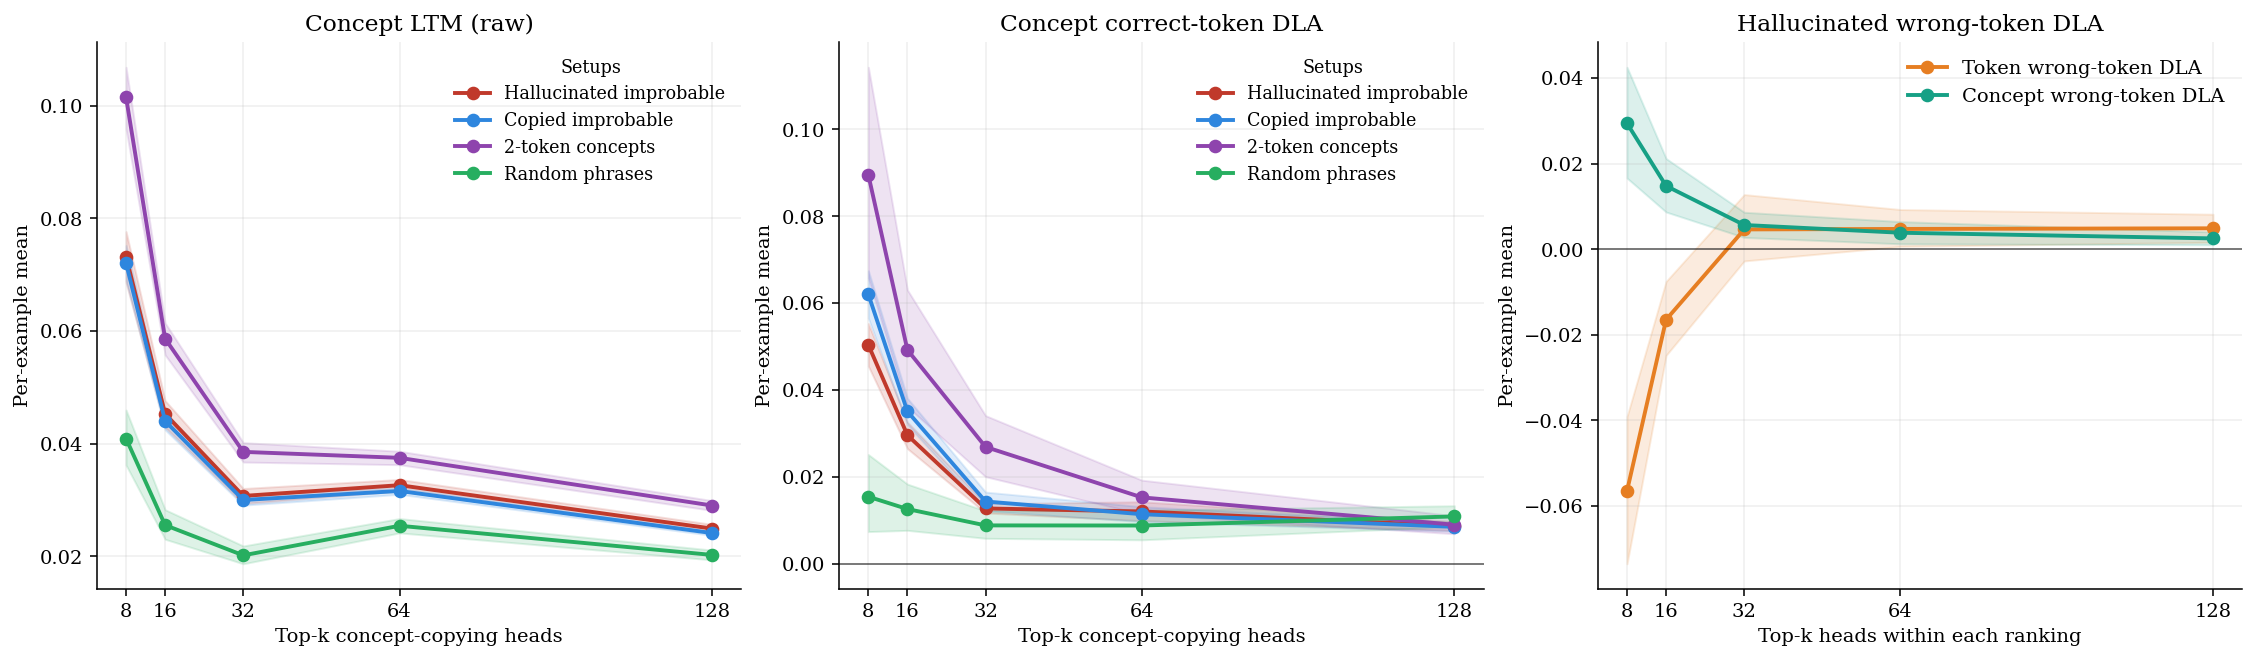

In [102]:
fig, axes, sweep = h1.plot_concept_k_sweep(CACHE, ks=(8, 16, 32, 64, 128))
display(sweep.round(6))

(<Figure size 1680x784 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 concept-head LTM'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 concept-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

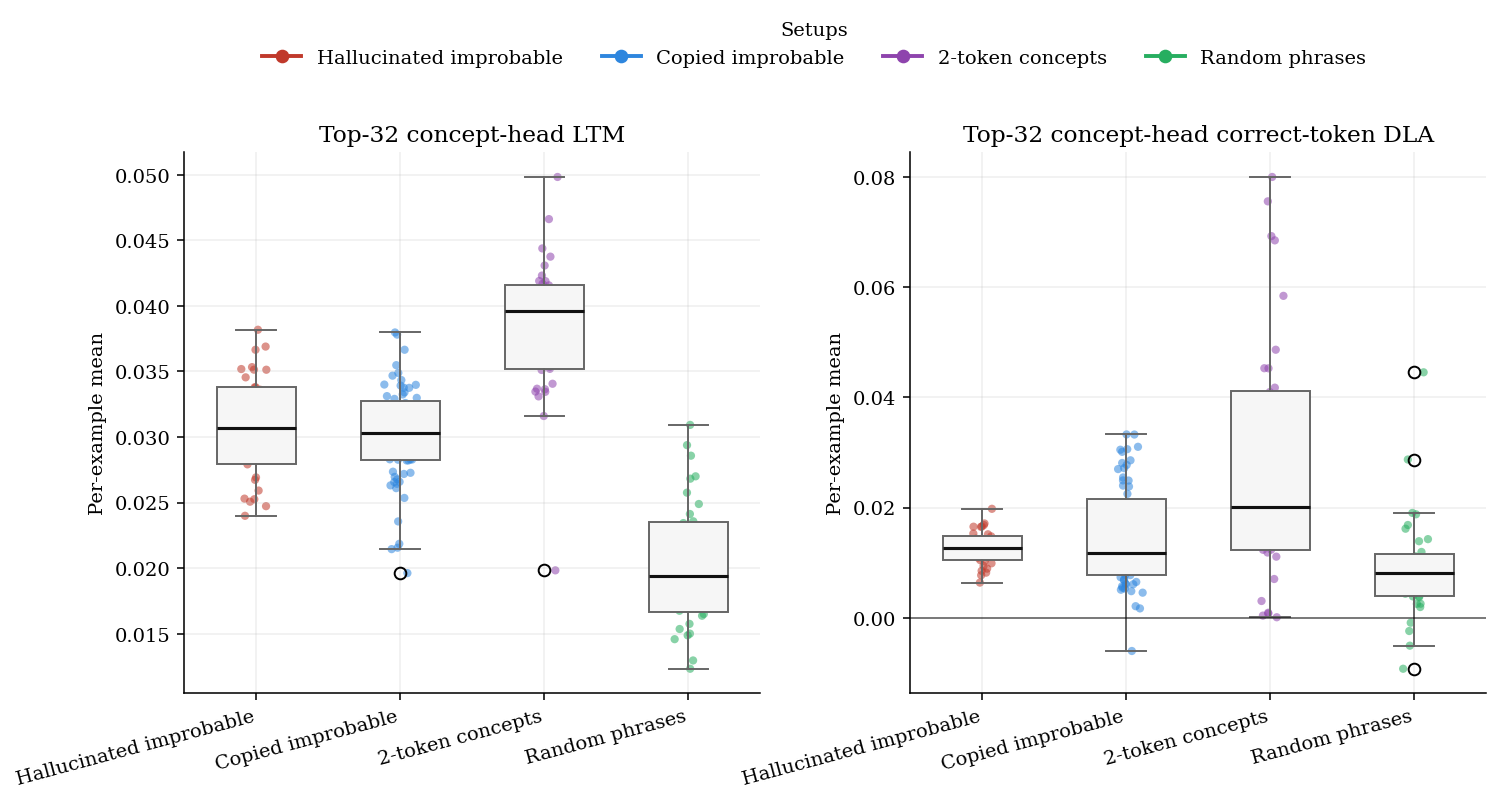

In [103]:
h1.plot_concept_distribution_panels(CACHE, DEFAULT_TOP_K)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 concept heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

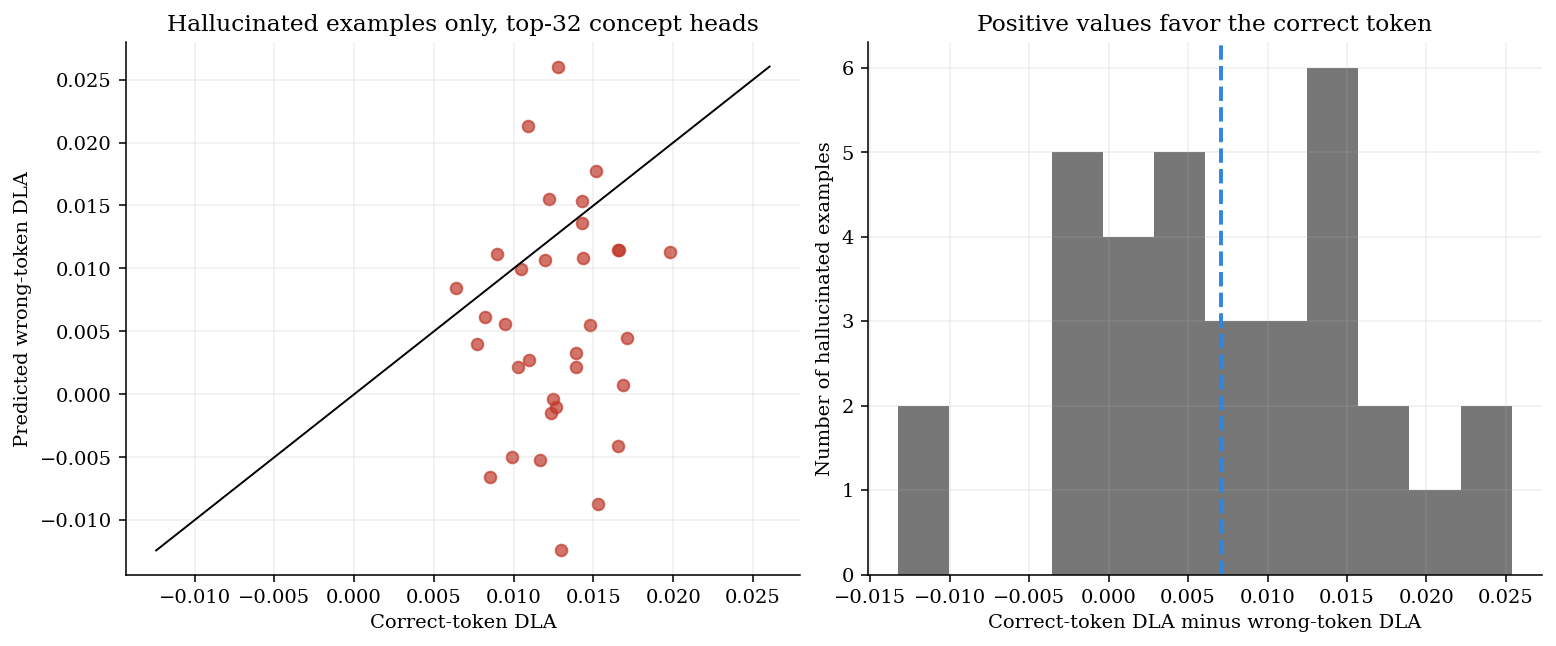

In [104]:
h1.plot_concept_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1890x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 concept heads: LTM'}>,
        <Axes: title={'center': 'Top-16 concept heads: DLA'}>],
       dtype=object))

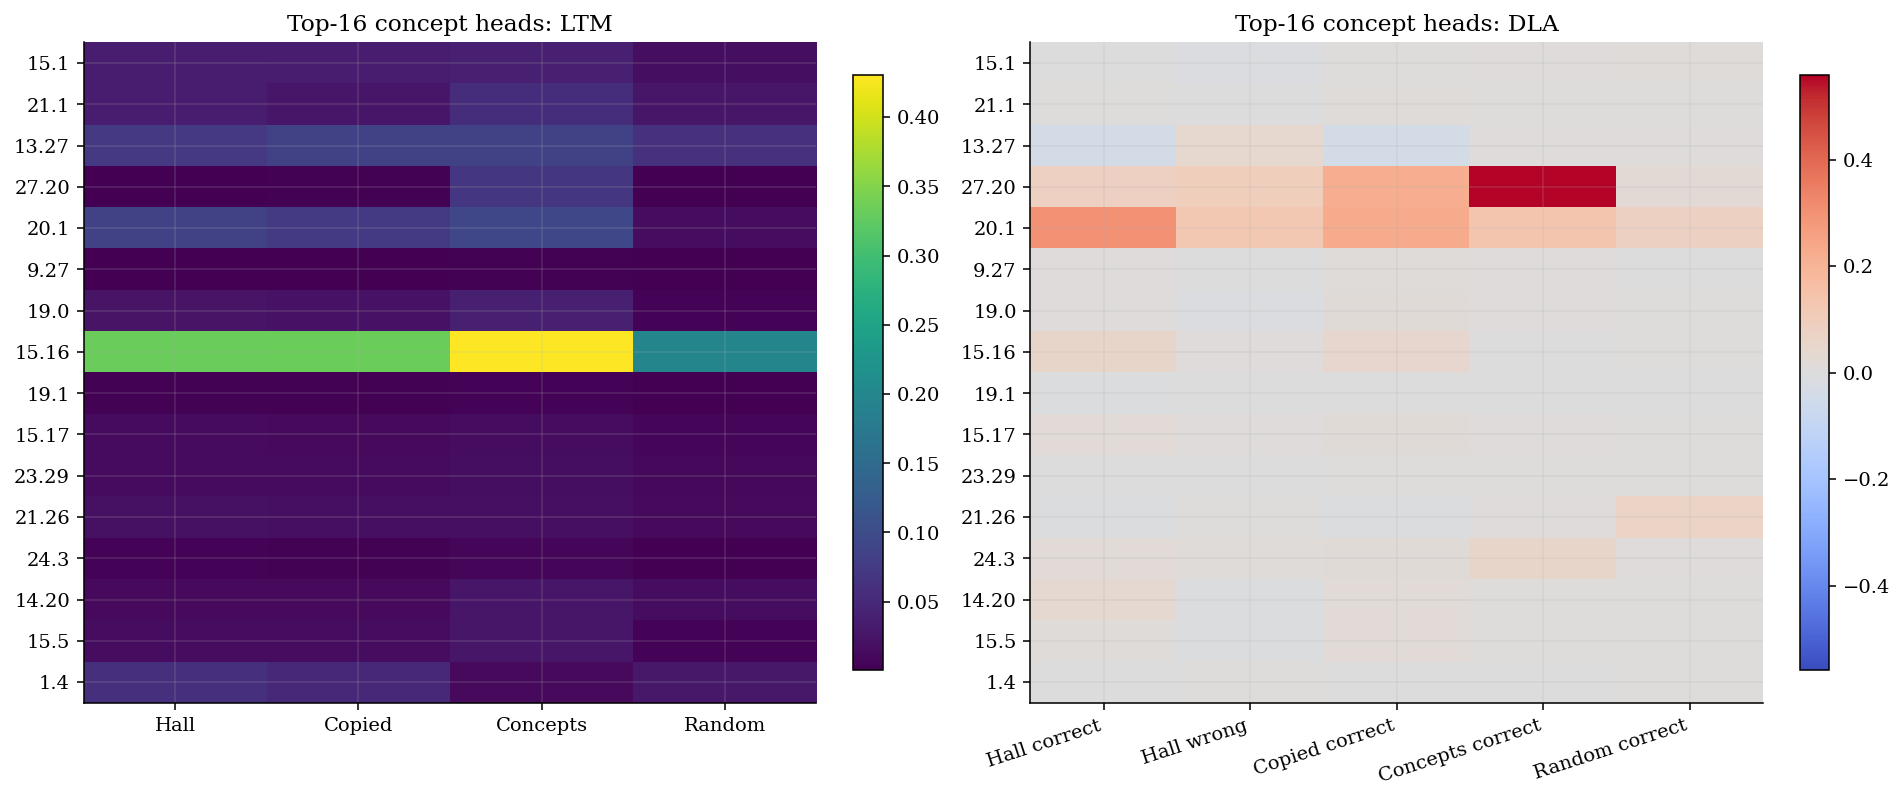

In [105]:
h1.plot_concept_head_heatmap(CACHE, top_k=16)

WindowsPath('D:/uni/courses/S2026/CS_7180/Project/improbable-bigram-causality/dual-route-induction/scripts/concept_head_figures')

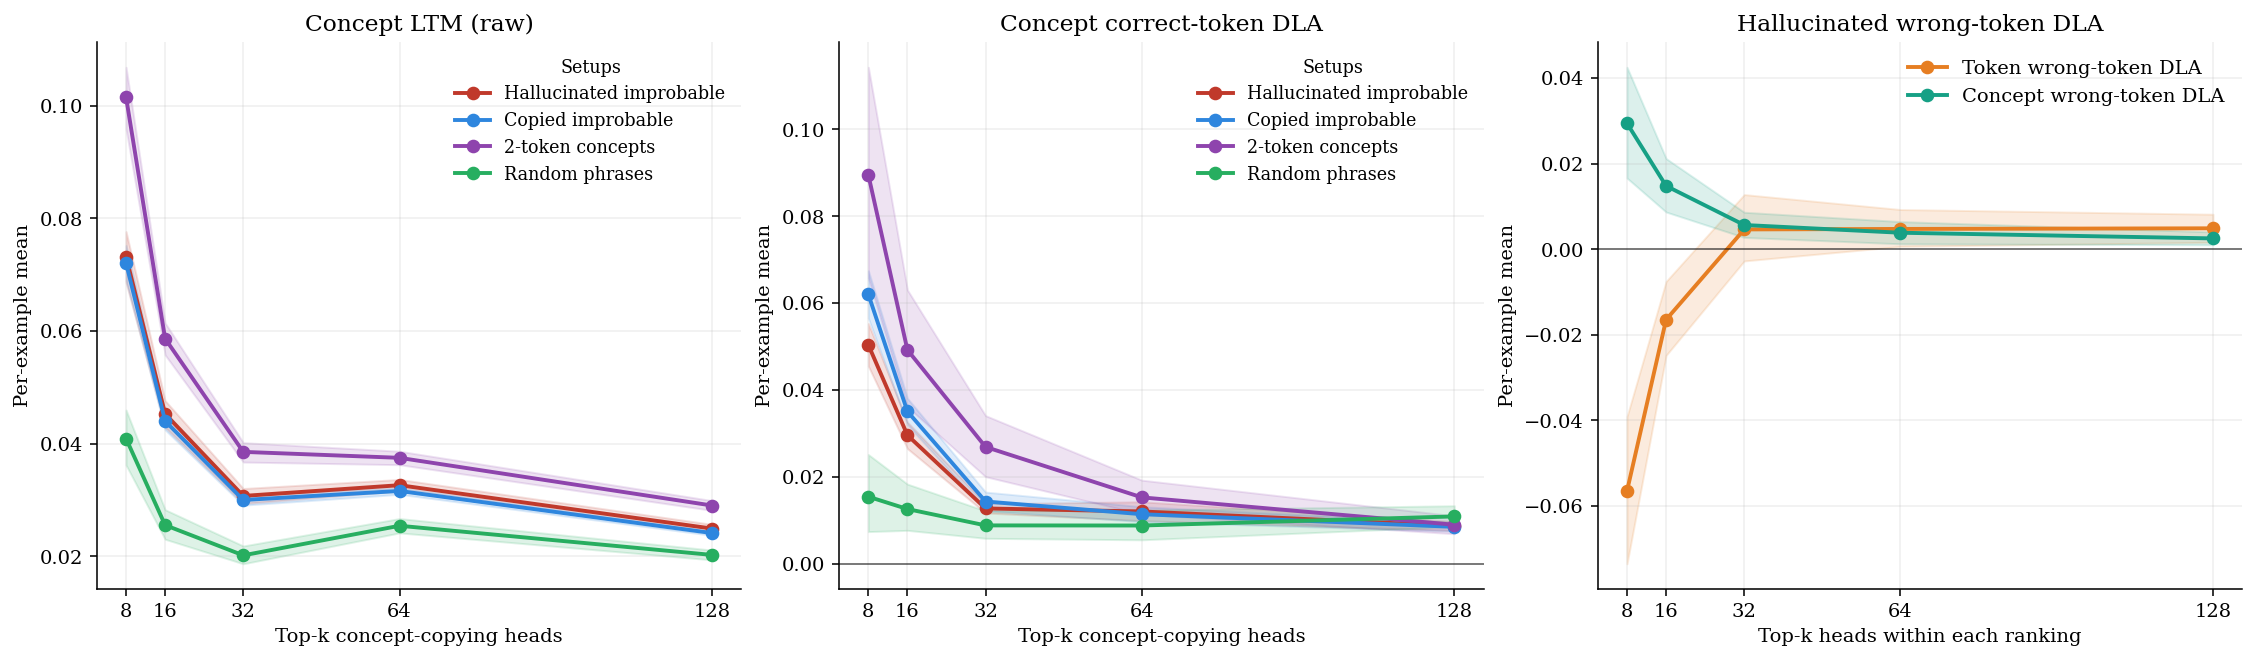

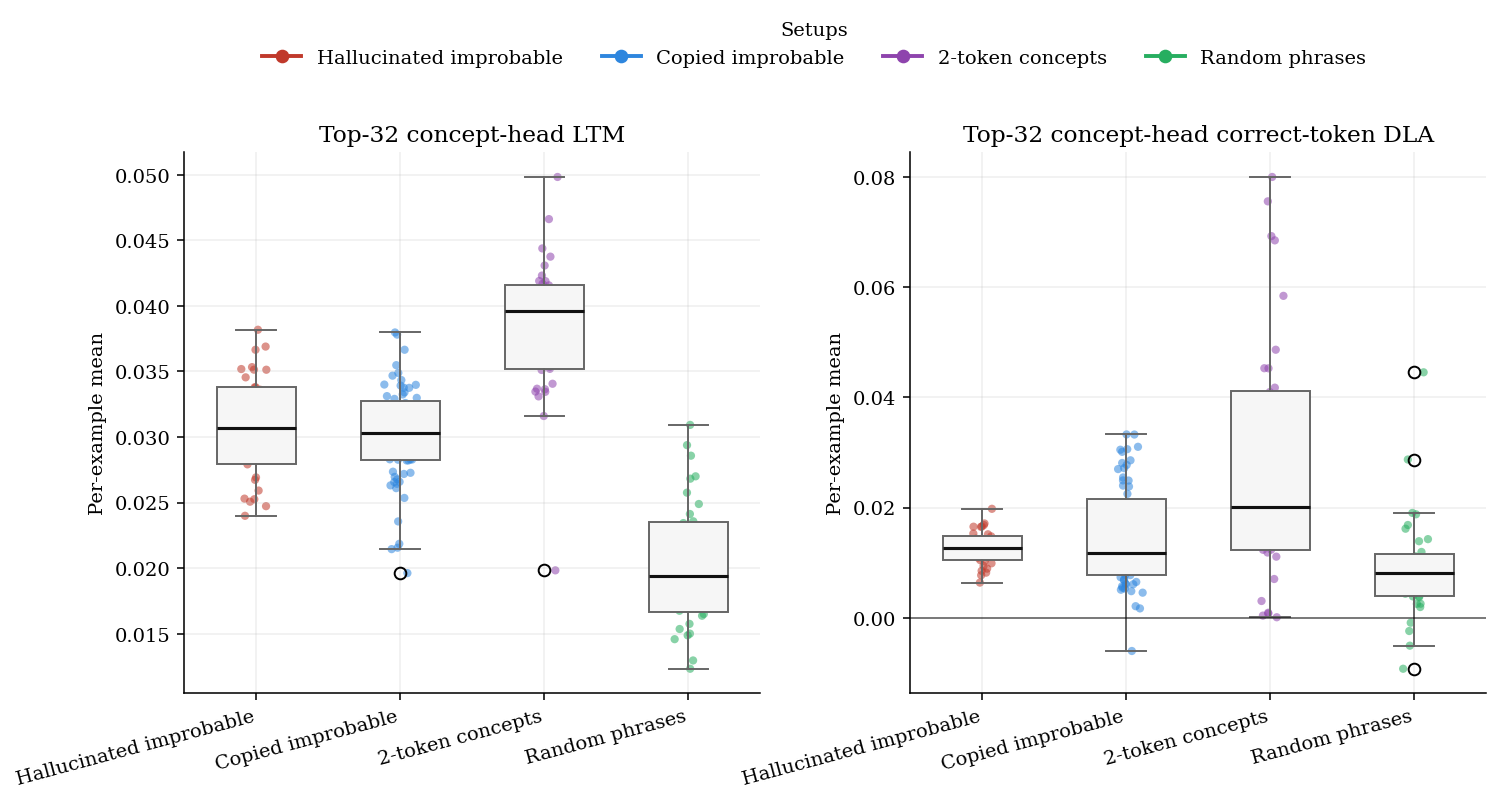

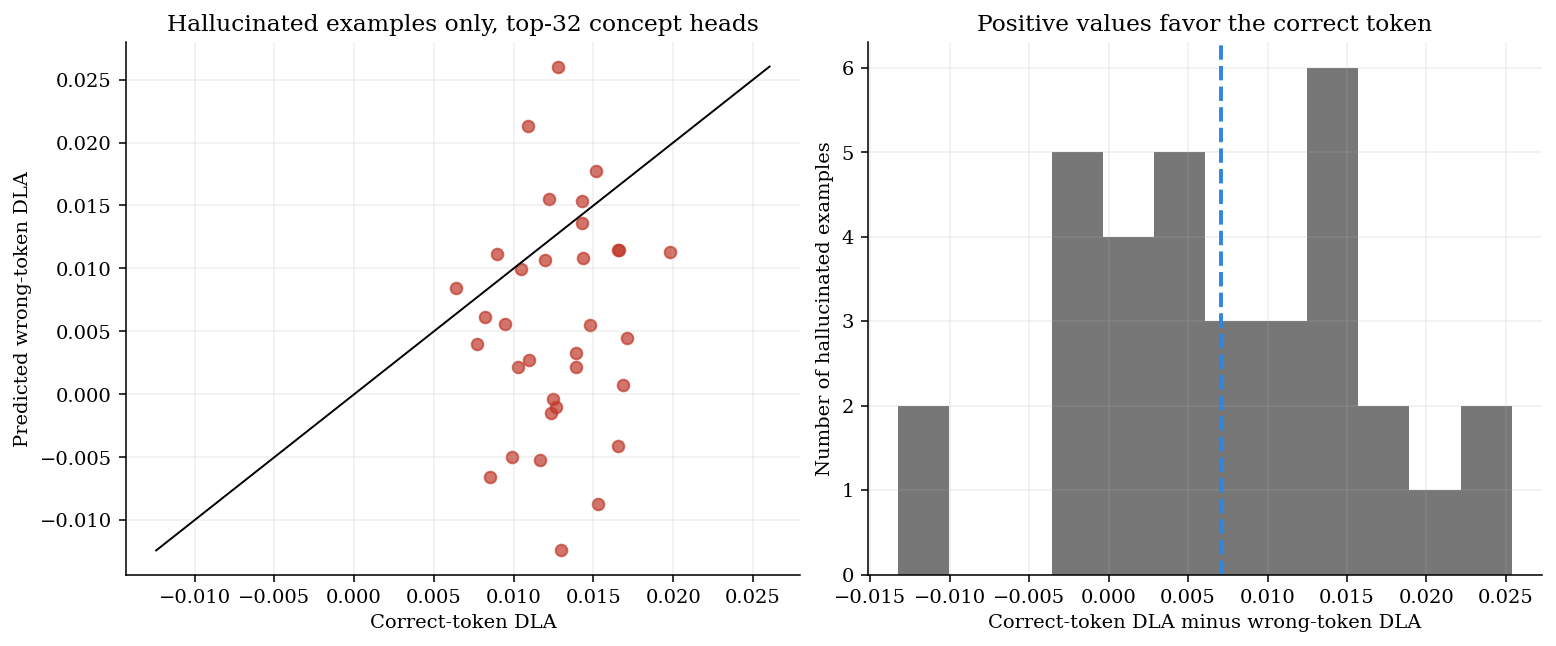

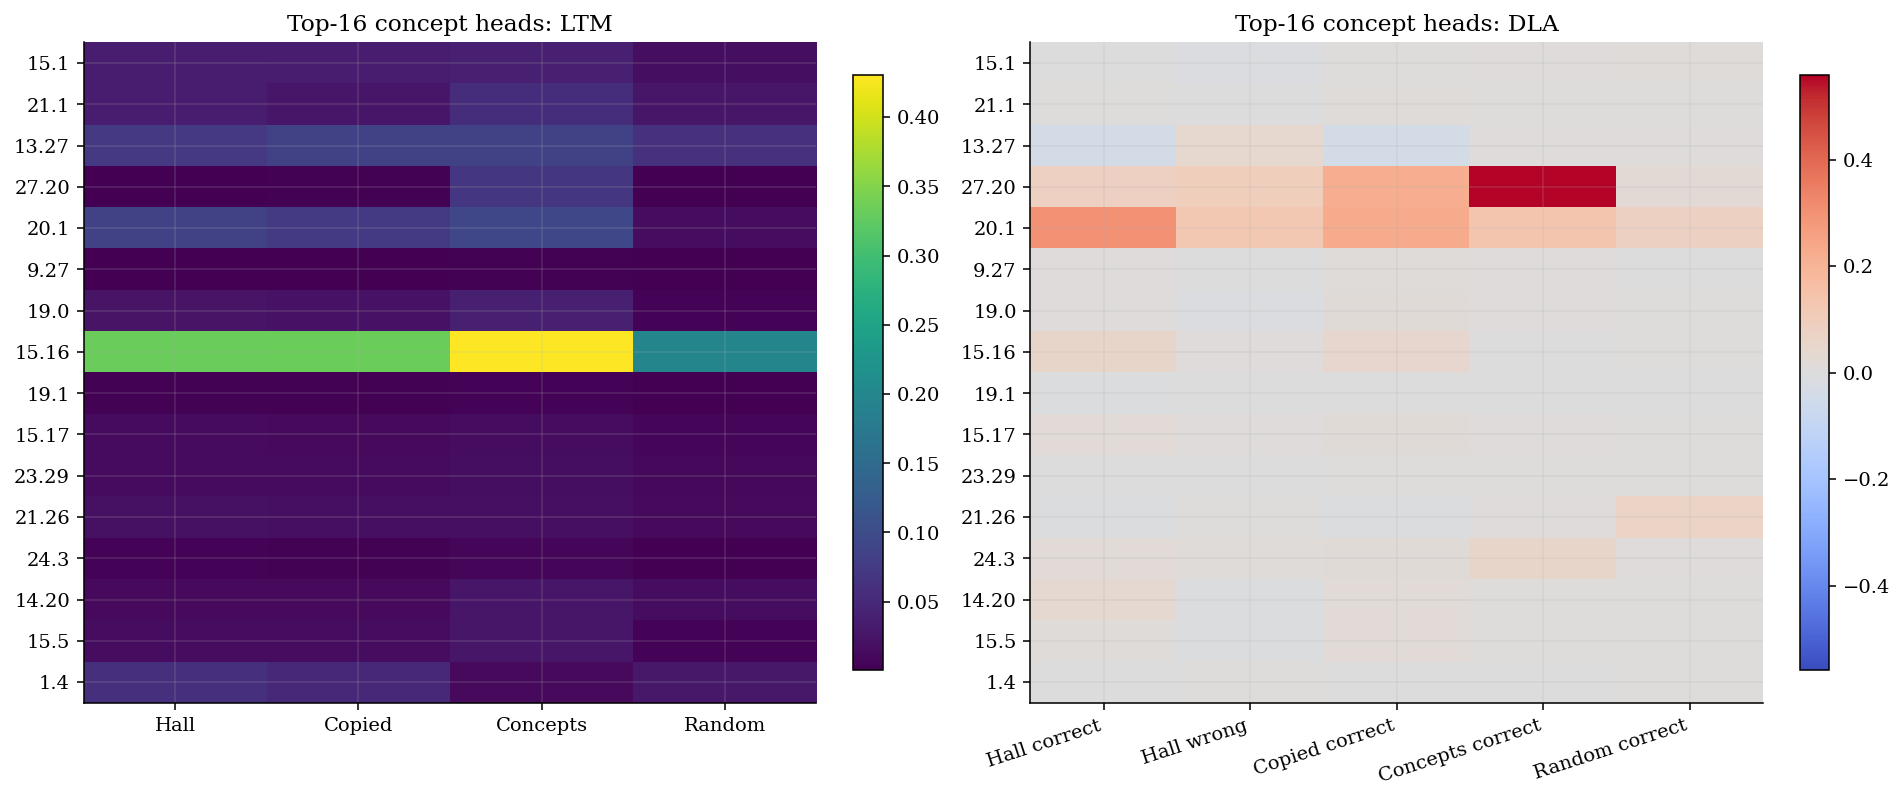

In [106]:
SAVE_DIR = ROOT / "scripts" / "concept_head_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_concept_k_sweep(
    CACHE, ks=(8, 16, 32, 64, 128), save_path=SAVE_DIR / "concept_k_sweep.png"
)
_ = h1.plot_concept_distribution_panels(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_distributions.png"
)
_ = h1.plot_concept_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_hallucinated_dla_pair.png"
)
_ = h1.plot_concept_head_heatmap(
    CACHE, top_k=16, save_path=SAVE_DIR / "concept_top_heads.png"
)
SAVE_DIR